In [21]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import  pyplot as plt 

In [7]:
def read_data(dataset, model, layer, basis_name):
    model = model
    layer = layer
    df = pd.read_csv(
        f"../../artifacts/2024-02-s21/experiments/3-accuracy-with-gamma/{dataset}/{model}/{layer}/{basis_name}.csv"
    )
    return df

read_data(
    dataset="cifar100-people",
    model="cifar100-resnet18-v1",
    layer="layer4",
    basis_name="pca--gamma0.0",
)

,layer,k,acc
0,layer4,1,0.200
1,layer4,2,0.364
2,layer4,3,0.532
3,layer4,4,0.622
4,layer4,5,0.614
5,layer4,6,0.616
6,layer4,7,0.614
7,layer4,8,0.616
8,layer4,9,0.614
9,layer4,10,0.612


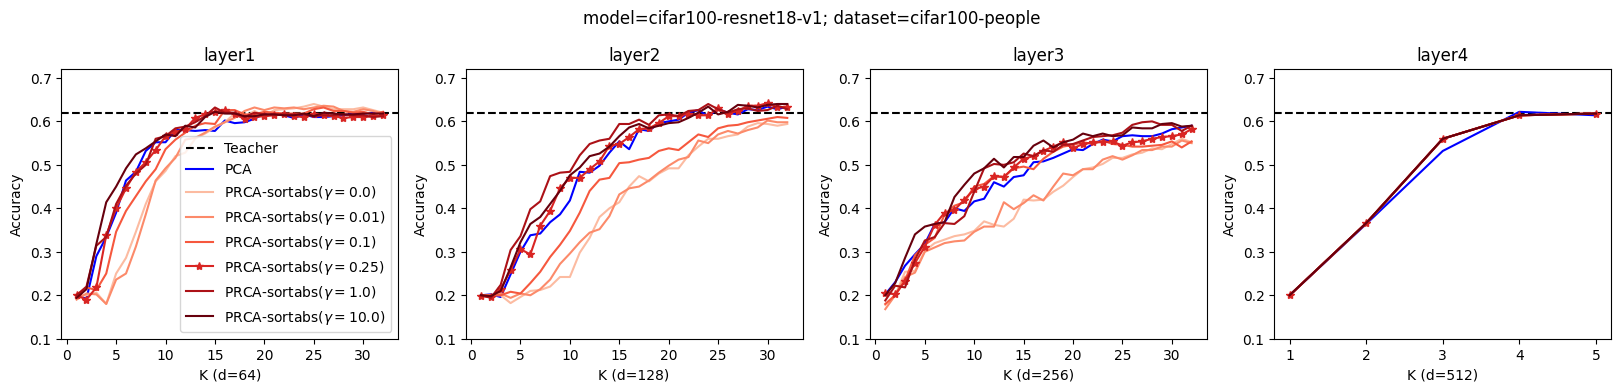

In [63]:
def alias(name):
    if "pca" in name:
        return "PCA"
    elif "prca" in name:
        gamma = name.split("--gamma")[1]
        return f"PRCA-sortabs($\\gamma={gamma}$)"
    else:
        raise
        
def color(name):
    if "pca" in name:
        return "blue"
    elif "prca-sortabs" in name:
        return "red"
    else:
        raise
        
def viz(
    dataset,
    model,
    arr_layers
):
    
    ncols = len(arr_layers)
    plt.figure(figsize=(5*ncols, 3.5))
    plt.suptitle(f"model={model}; dataset={dataset}", y=1.05)
    arr_basis_names = [
        "pca--gamma0.0",
        "prca-sortabs--gamma0.0",
        "prca-sortabs--gamma0.01",
        "prca-sortabs--gamma0.1",
#         "prca-sortabs--gamma0.2",
        "prca-sortabs--gamma0.25",
#         "prca-sortabs--gamma0.5",
#         "prca-sortabs--gamma0.75",
        "prca-sortabs--gamma1.0",
        "prca-sortabs--gamma10.0",
#         "prca-sortabs--gamma100.0",
    ]
    
    
    color_index = np.linspace(0.1, 1, len(arr_basis_names))
    cmap_reds = mpl.colormaps.get_cmap("Reds")
    
    for lix, (layer, max_k) in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        
        plt.title(layer)
        
        for bix, basis_name in enumerate(arr_basis_names):
            df = read_data(
                dataset=dataset,
                model=model,
                layer=layer,
                basis_name=basis_name
            )
            dims = df.k.max()
            
            if bix == 0:
                ref_acc = df[df.k == df.k.max()].acc.values[0]
                plt.axhline(
                    ref_acc, ls="--", label="Teacher", 
                    color="k"
                )
                plt.ylim([0.1, ref_acc+0.1])
            _df = df[df.k <= max_k]

            plt.plot(
                _df.k,
                _df.acc,
                marker="*" if basis_name == "prca-sortabs--gamma0.25" else "",
                color="blue" if "pca" in basis_name else cmap_reds(color_index[bix]),
                label=alias(basis_name)
            )
            plt.xlabel(f"K (d={dims})")
        
        plt.ylabel("Accuracy")
        
        if lix == 0:
            plt.legend()
viz(
    dataset="cifar100-people",
    model="cifar100-resnet18-v1",
    arr_layers=[
        ("layer1", 32),
        ("layer2", 32),
        ("layer3", 32),
        ("layer4", 5),
    ]
)

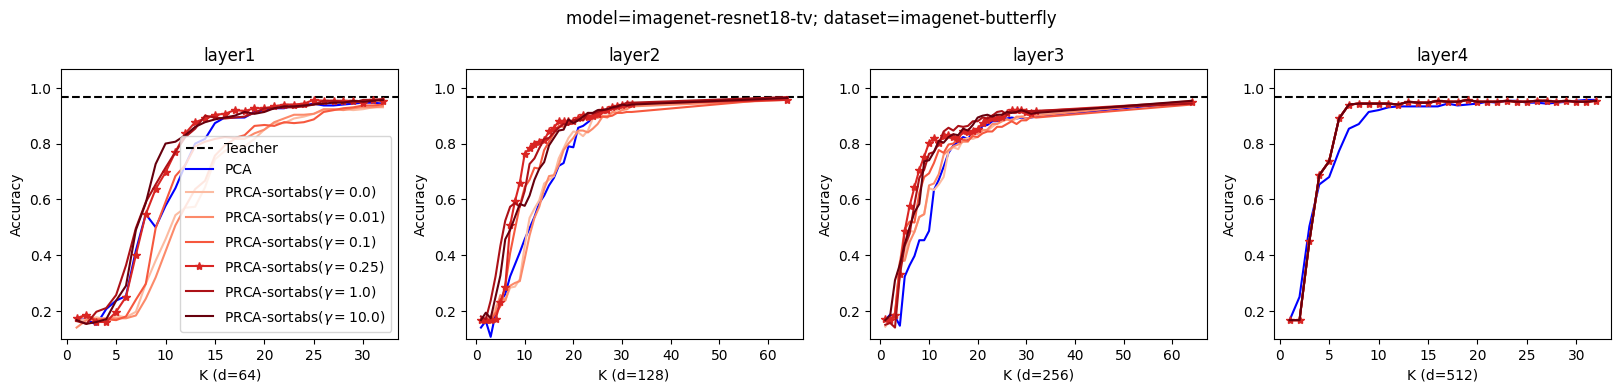

In [64]:
viz(
    dataset="imagenet-butterfly",
    model="imagenet-resnet18-tv",
    arr_layers=[
        ("layer1", 32),
        ("layer2", 64),
        ("layer3", 64),
        ("layer4", 32),
    ]
)

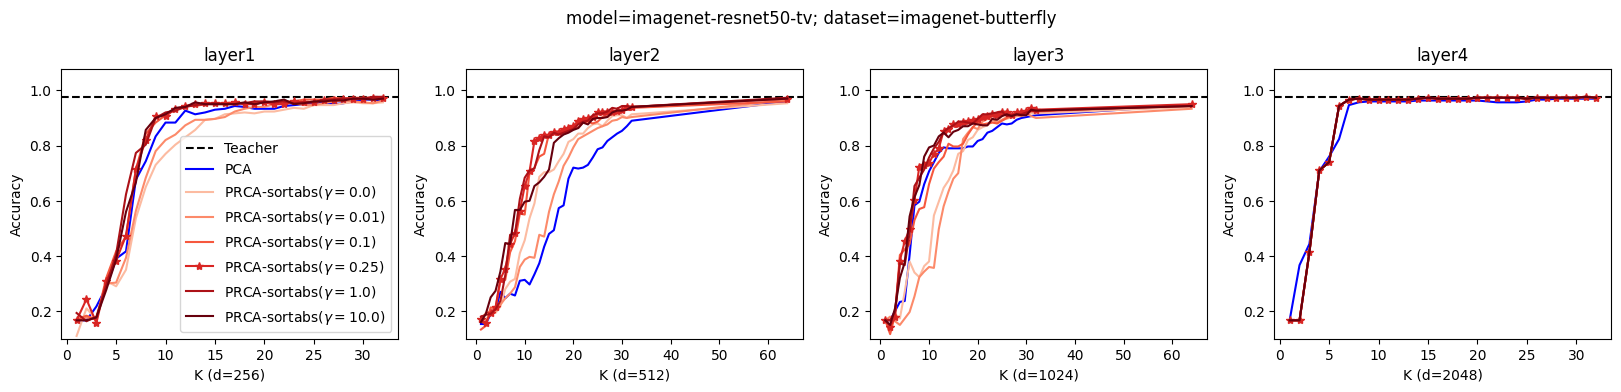

In [68]:
viz(
    dataset="imagenet-butterfly",
    model="imagenet-resnet50-tv",
    arr_layers=[
        ("layer1", 32),
        ("layer2", 64),
        ("layer3", 64),
        ("layer4", 32),
    ]
)

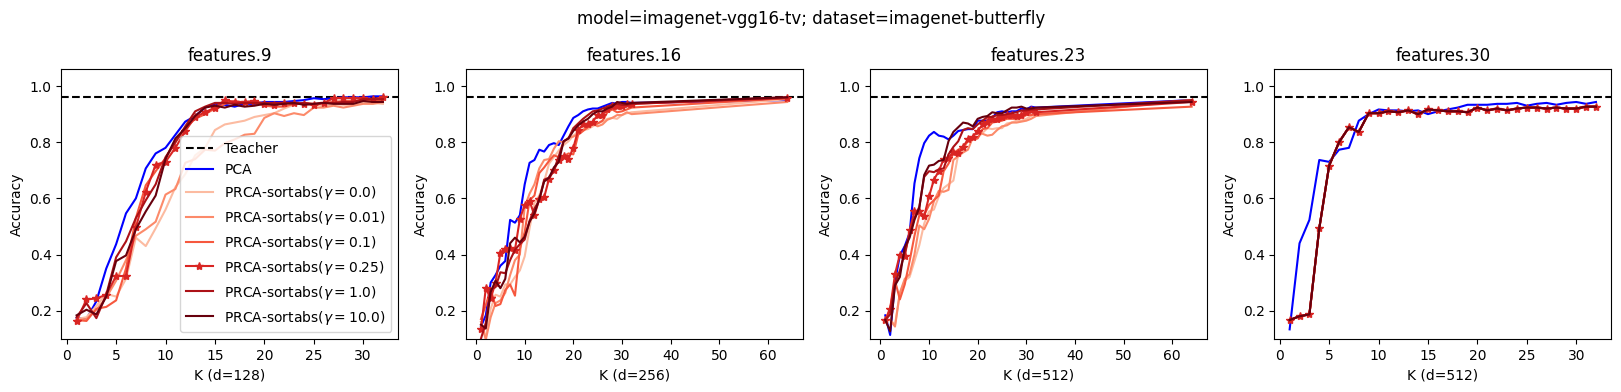

In [67]:
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_layers=[
        ("features.9", 32),
        ("features.16", 64),
        ("features.23", 64),
        ("features.30", 32),
    ]
)